In [2]:
import h2o
import joblib
from h2o.automl import H2OAutoML
#from h2o.exceptions import H2OValueError
from pprint import pprint
import os
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "1.8.0_362"; OpenJDK Runtime Environment (build 1.8.0_362-8u372-ga~us1-0ubuntu1~22.04-b09); OpenJDK 64-Bit Server VM (build 25.362-b09, mixed mode)
  Starting server from /home/angel/.local/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp_lzhyovz
  JVM stdout: /tmp/tmp_lzhyovz/h2o_angel_started_from_python.out
  JVM stderr: /tmp/tmp_lzhyovz/h2o_angel_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.40.0.4
H2O_cluster_version_age:,1 month and 17 days
H2O_cluster_name:,H2O_from_python_angel_2ekvoe
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.395 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [3]:
name = "10_to_predict_1_balanced"
print(f"Building AutoML models for {name}")

# Define the path to your data file
filepath = "/home/angel/Workspace/h2o/datasets/10_to_predict_3_balanced.csv"

# Check if the file exists
if not os.path.isfile(filepath):
    raise Exception("File not found at path: {}".format(filepath))

dset = h2o.import_file(filepath)
train, test = dset.split_frame(ratios=[0.7], seed=1234)
# Identify predictors and response
x = train.columns
y = "Status"
x.remove(y)
x.remove("CIF")

# For binary classification, response should be a factor
train[y] = train[y].asfactor()
test[y] = test[y].asfactor()

# Run AutoML for 20 base models
aml = H2OAutoML(max_models=20, seed=1234, sort_metric="auc")
aml.train(x=x, y=y, training_frame=train)

#h2o.save_model(aml,name+"_autoML.model")
try:
    aml.save_mojo(aml,name+"_autoML_mojo")
except:
    print(f"ERROR saving autoML model {name}_autoML_mojo")
    pass

try:
    h2o.save_model(aml,name+"_autoML")
except:
    print(f"ERROR saving autoML model {name}_autoML")
    pass

# View the AutoML Leaderboard
#lb = aml.leaderboard
#lb.head(rows=lb.nrows)  # Print all rows instead of default (10 rows)
# Get leaderboard with all possible columns
lb = h2o.automl.get_leaderboard(aml, extra_columns = "ALL")
print(lb)


Building AutoML models for 10_to_predict_1_balanced
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
ERROR saving autoML model 10_to_predict_1_balanced_autoML_mojo
ERROR saving autoML model 10_to_predict_1_balanced_autoML
model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse        mse    training_time_ms    predict_time_per_row_ms  algo
StackedEnsemble_AllModels_1_AutoML_1_20230614_132707     0.991341   0.113137  0.990404               0.0412443  0.178314  0.0317958               12841                   0.021804  StackedEnsemble
StackedEnsemble_BestOfFamily_1_AutoML_1_20230614_132707  0.990431   0.119015  0.989292               0.0436638  0.183205  0.0335642                6879                   0.011913  StackedEnsemble
XGBoost_3_AutoML_1_20230614_132707                       0.9

#### Explaining the AutoML model

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
StackedEnsemble_AllModels_1_AutoML_1_20230614_132707,0.990289,0.116216,0.988685,0.0415604,0.180141,0.0324508,12841,0.036157,StackedEnsemble
XGBoost_grid_1_AutoML_1_20230614_132707_model_2,0.989102,0.123898,0.987598,0.0432609,0.185791,0.0345185,4756,0.004205,XGBoost
StackedEnsemble_BestOfFamily_1_AutoML_1_20230614_132707,0.988979,0.121714,0.986853,0.0415422,0.18348,0.033665,6879,0.016138,StackedEnsemble
XGBoost_grid_1_AutoML_1_20230614_132707_model_1,0.988744,0.133527,0.986645,0.0448218,0.189958,0.036084,5418,0.005372,XGBoost
XGBoost_grid_1_AutoML_1_20230614_132707_model_3,0.988684,0.126887,0.98611,0.0441117,0.18612,0.0346407,6937,0.005889,XGBoost
XGBoost_3_AutoML_1_20230614_132707,0.988515,0.126718,0.986081,0.0423976,0.184782,0.0341446,5006,0.005533,XGBoost
XGBoost_2_AutoML_1_20230614_132707,0.988037,0.139209,0.985669,0.0469801,0.192927,0.0372209,5683,0.004786,XGBoost
XGBoost_1_AutoML_1_20230614_132707,0.987907,0.130929,0.984838,0.0441185,0.188491,0.0355287,4828,0.005555,XGBoost
GBM_grid_1_AutoML_1_20230614_132707_model_2,0.984448,0.152111,0.981983,0.055532,0.208912,0.0436442,16549,0.012972,GBM
GBM_4_AutoML_1_20230614_132707,0.984192,0.156449,0.981483,0.0576692,0.211827,0.0448707,18235,0.012758,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## StackedEnsemble_AllModels_1_AutoML_1_20230614_132707

,Insolvent,Solvent,Error,Rate
Insolvent,3268.0,230.0,0.0658,(230.0/3498.0)
Solvent,61.0,3451.0,0.0174,(61.0/3512.0)
Total,3329.0,3681.0,0.0415,(291.0/7010.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

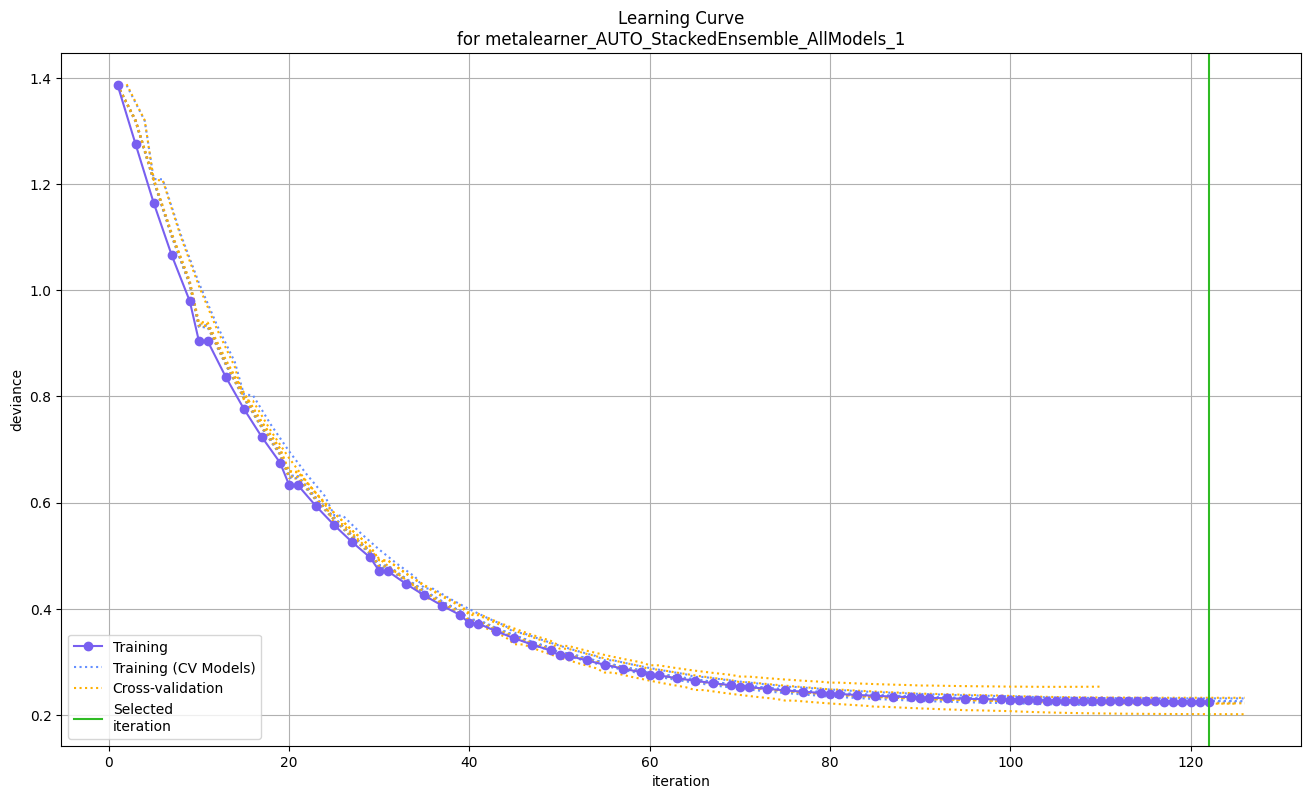

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

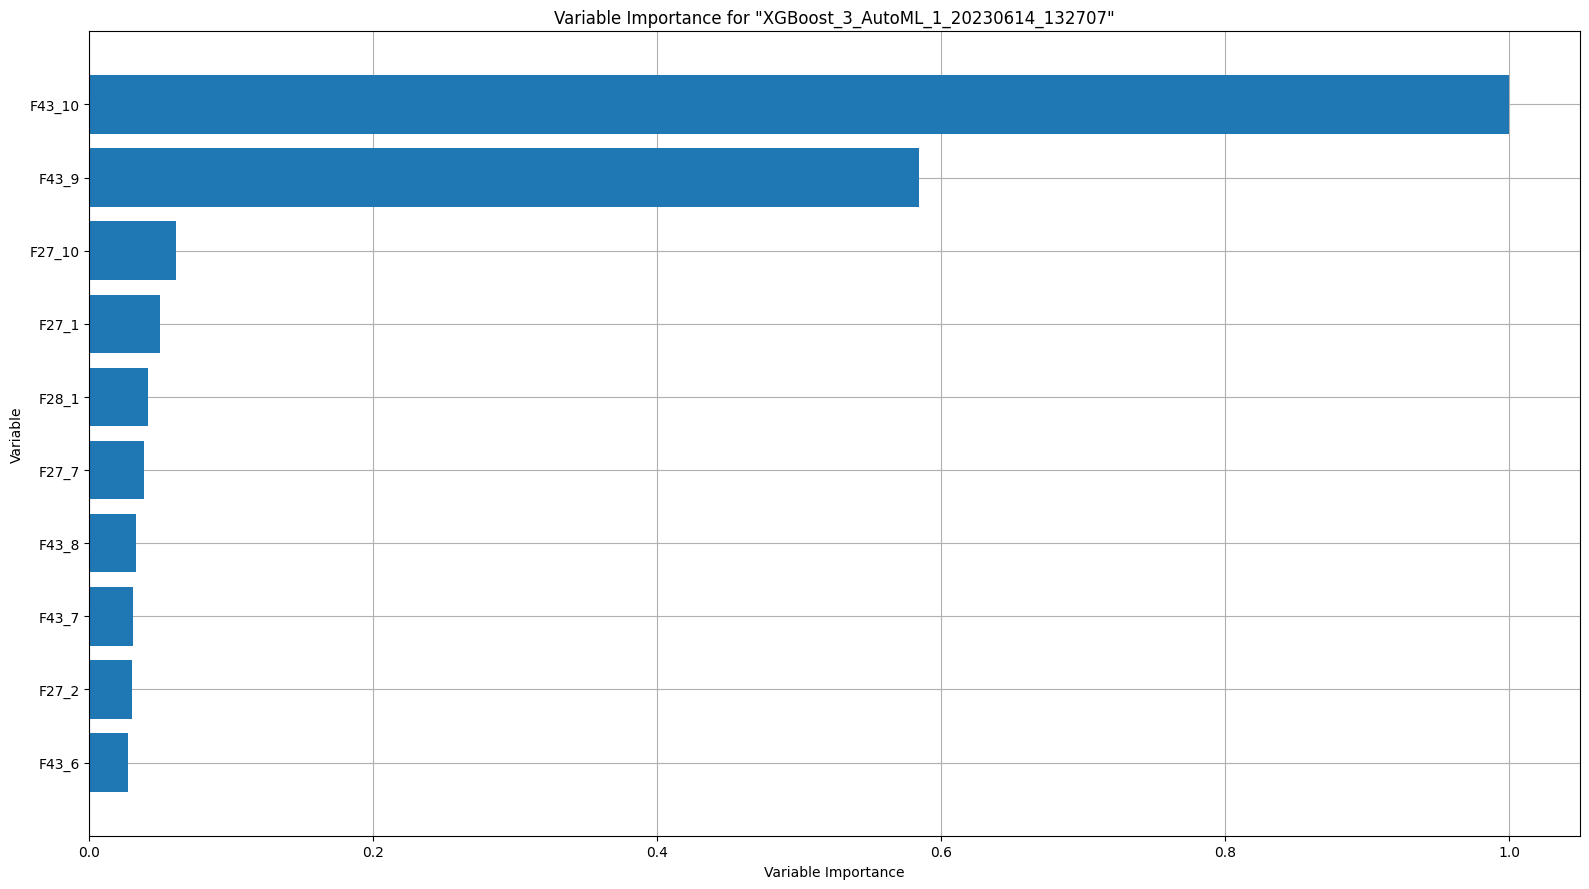

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

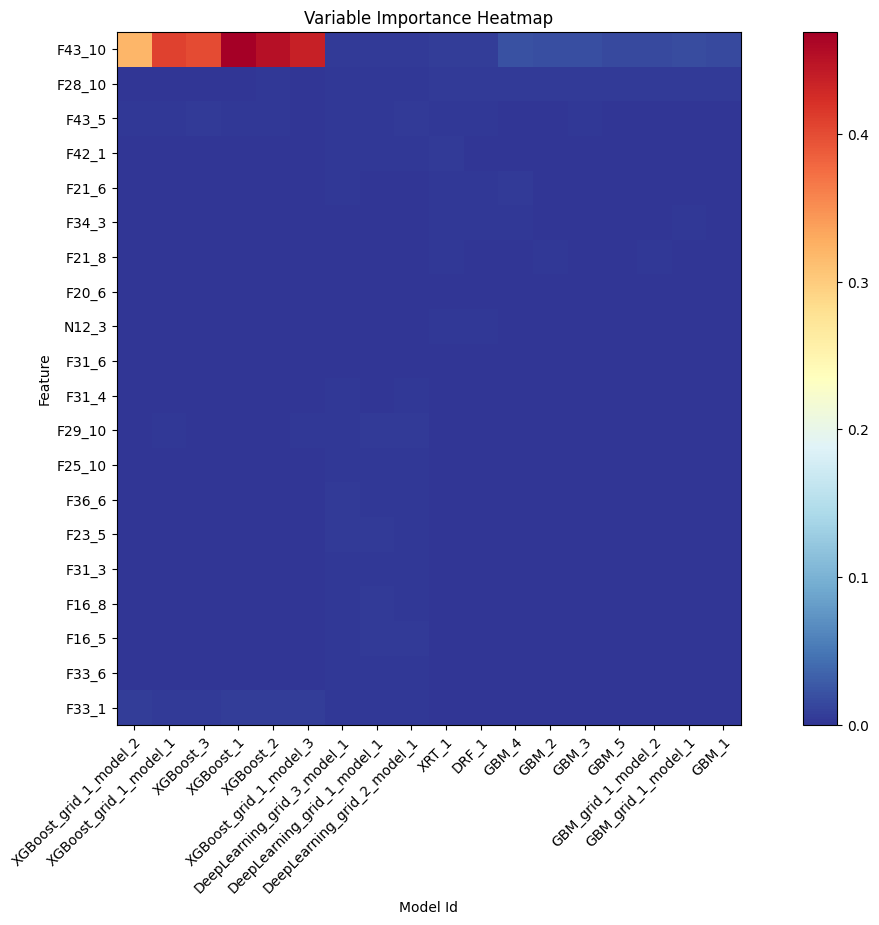

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

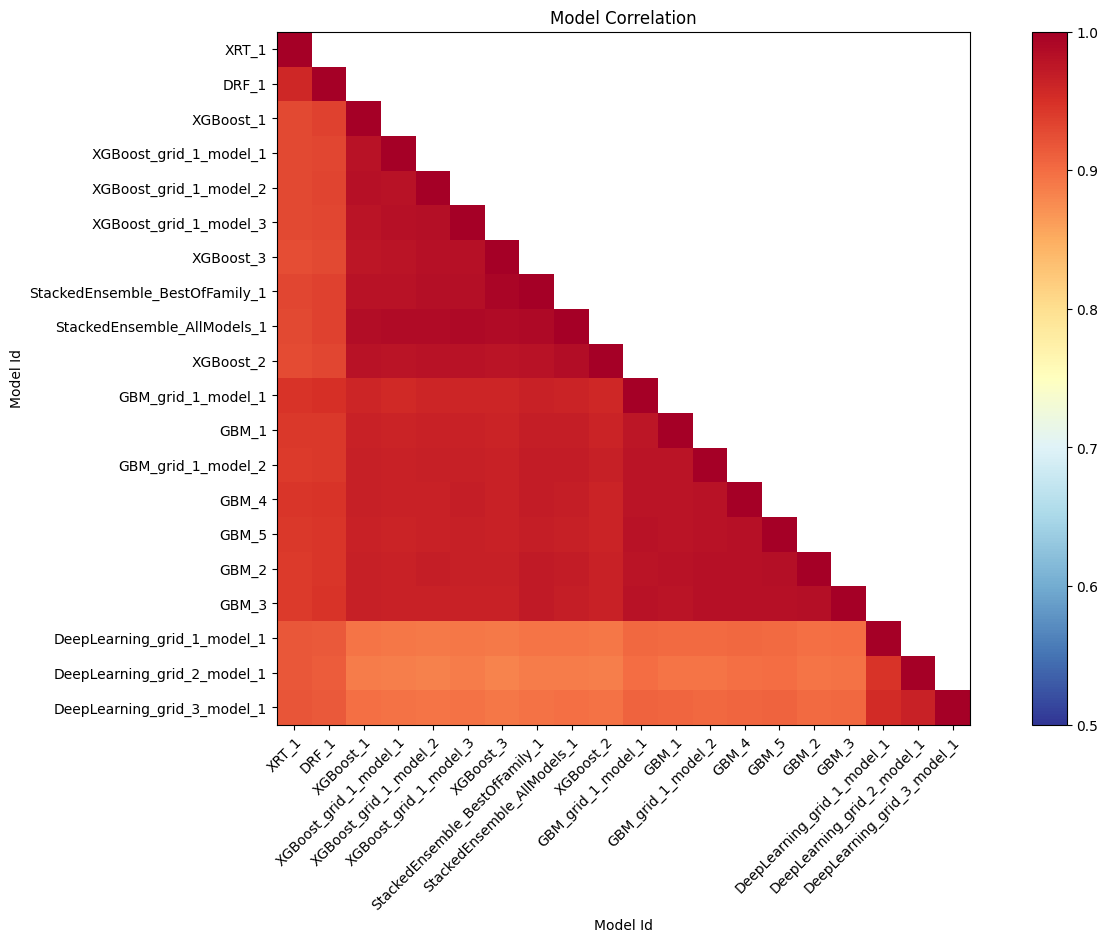

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

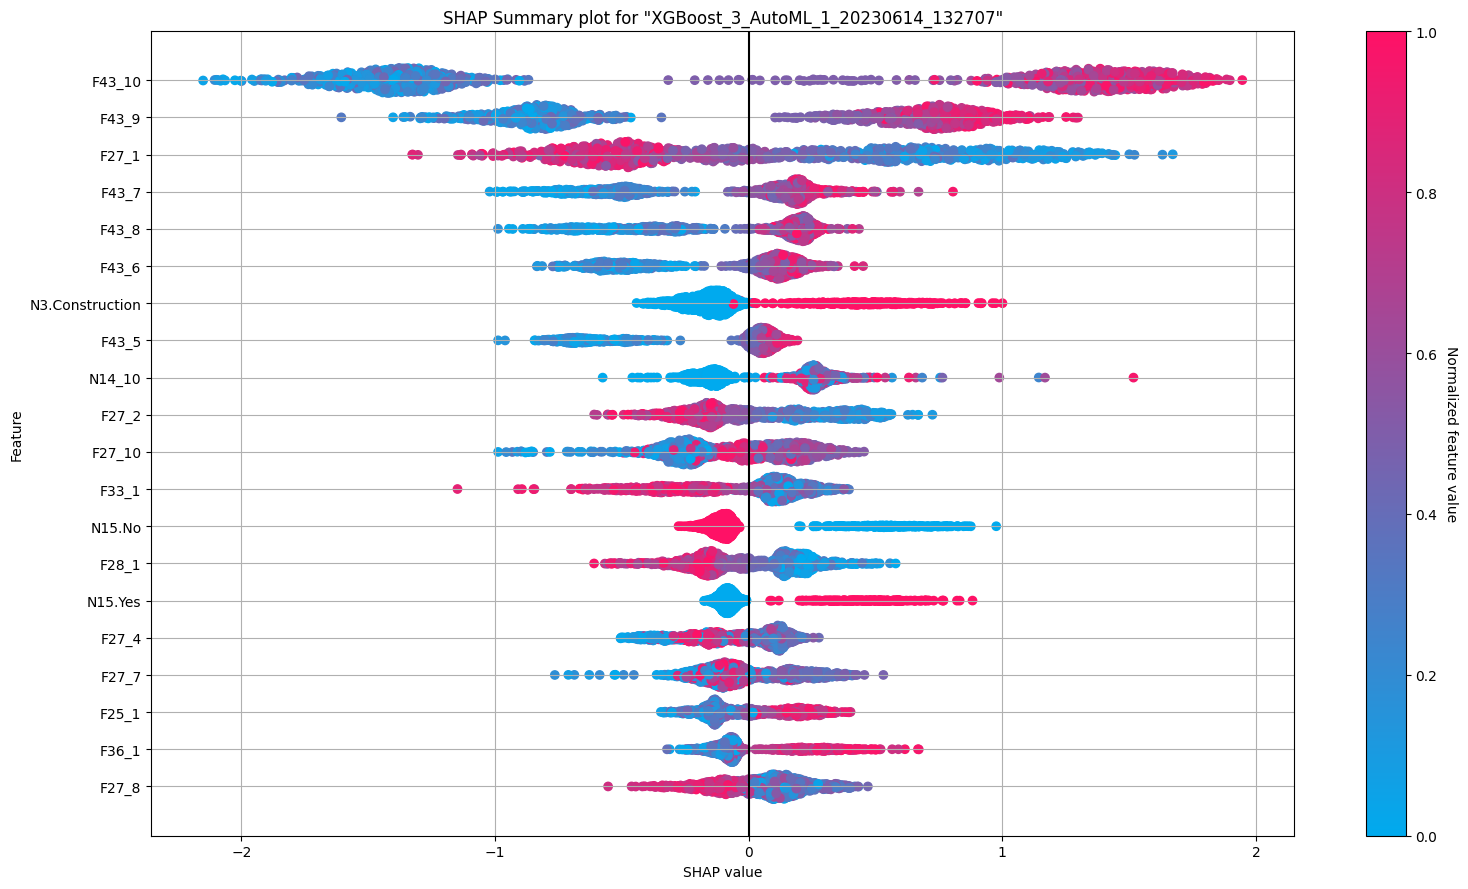

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

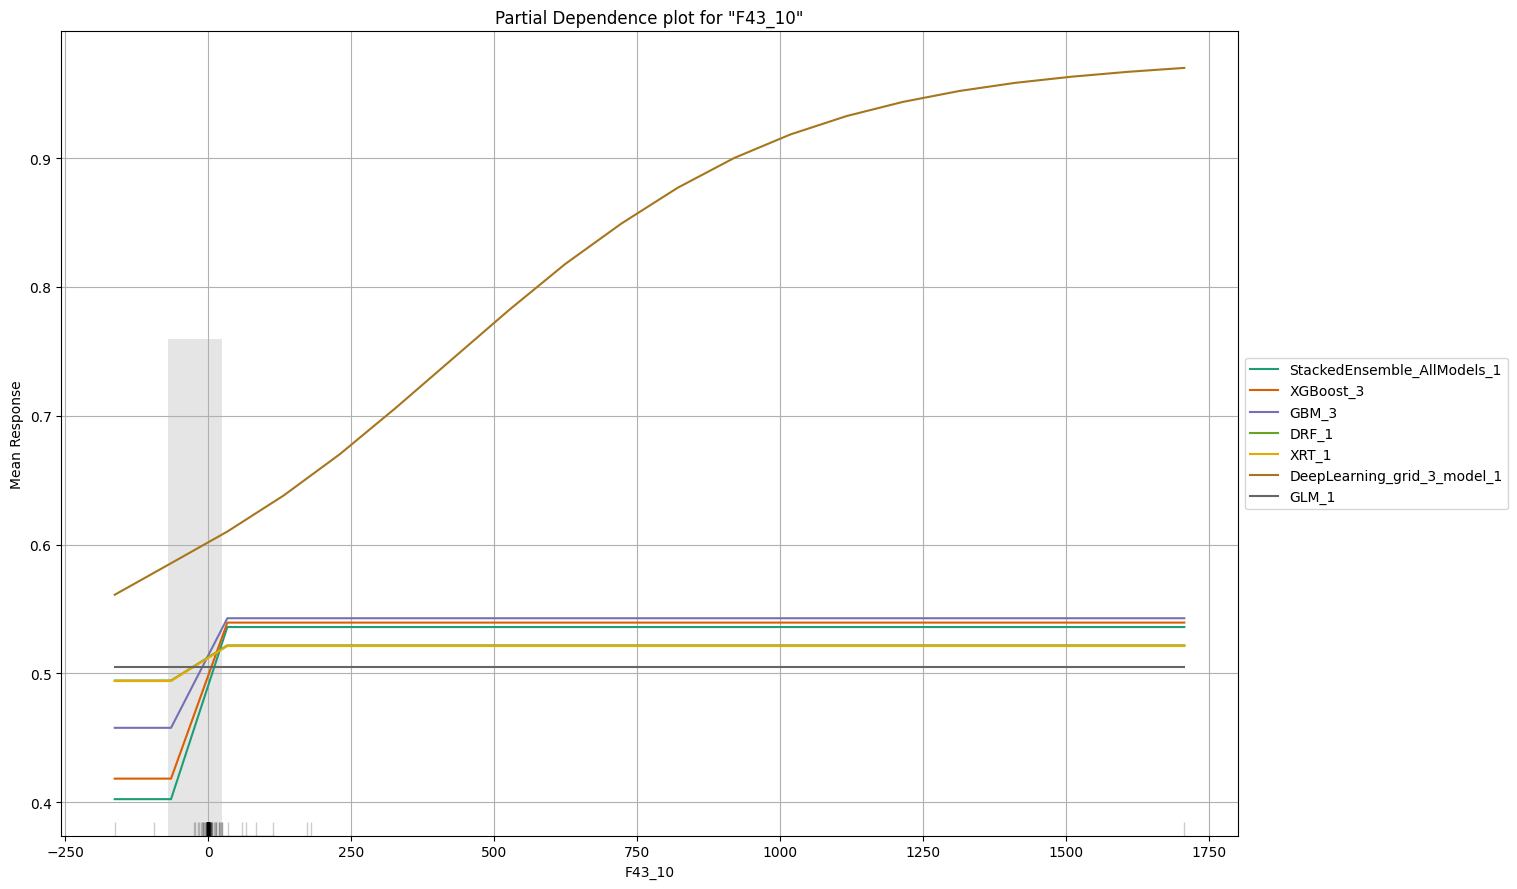

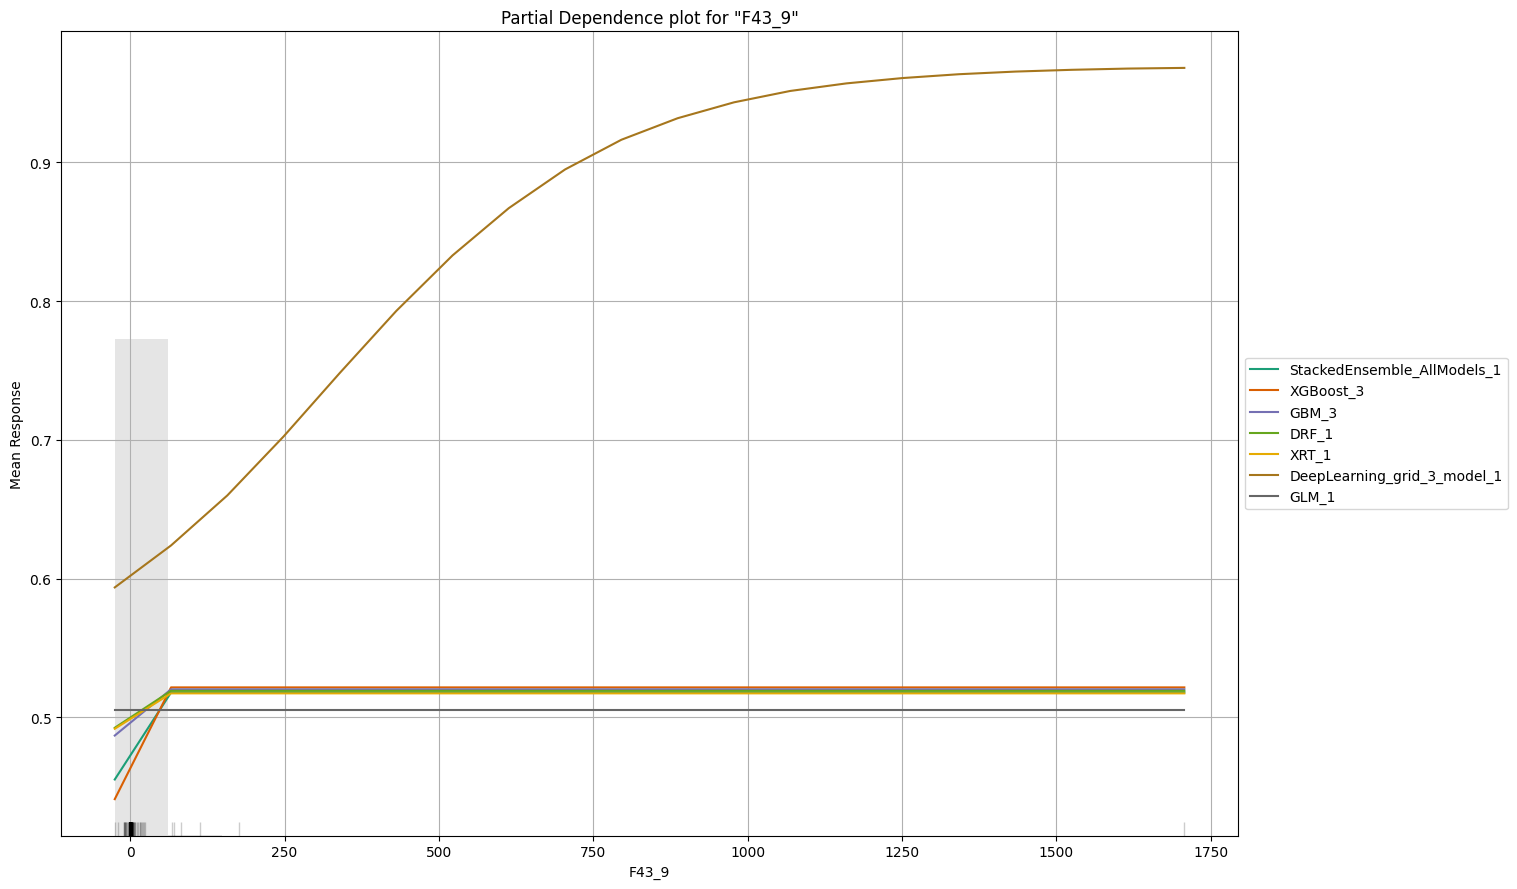

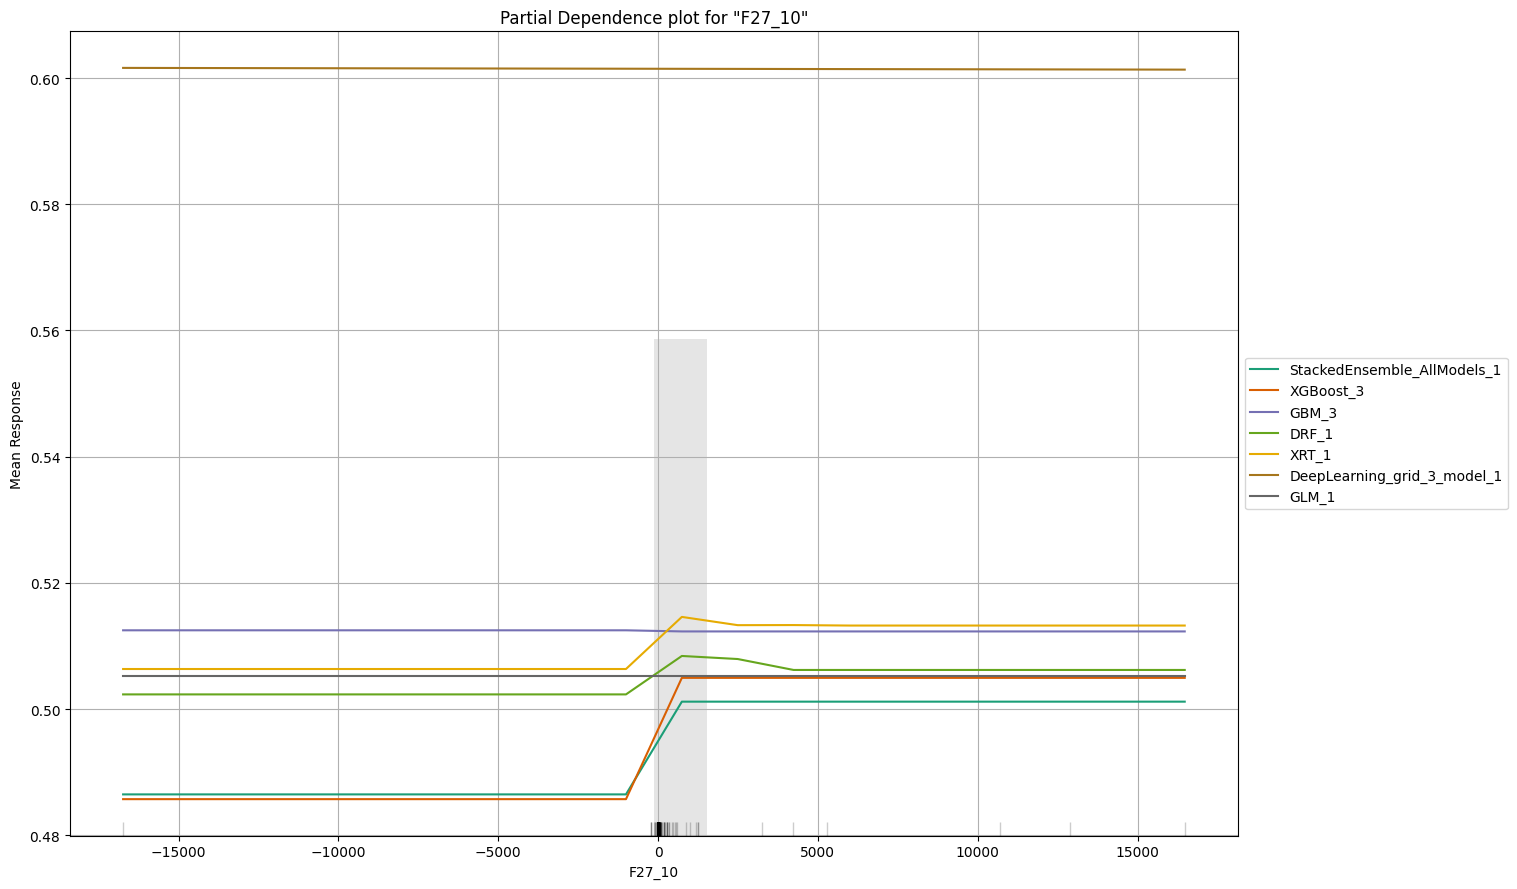

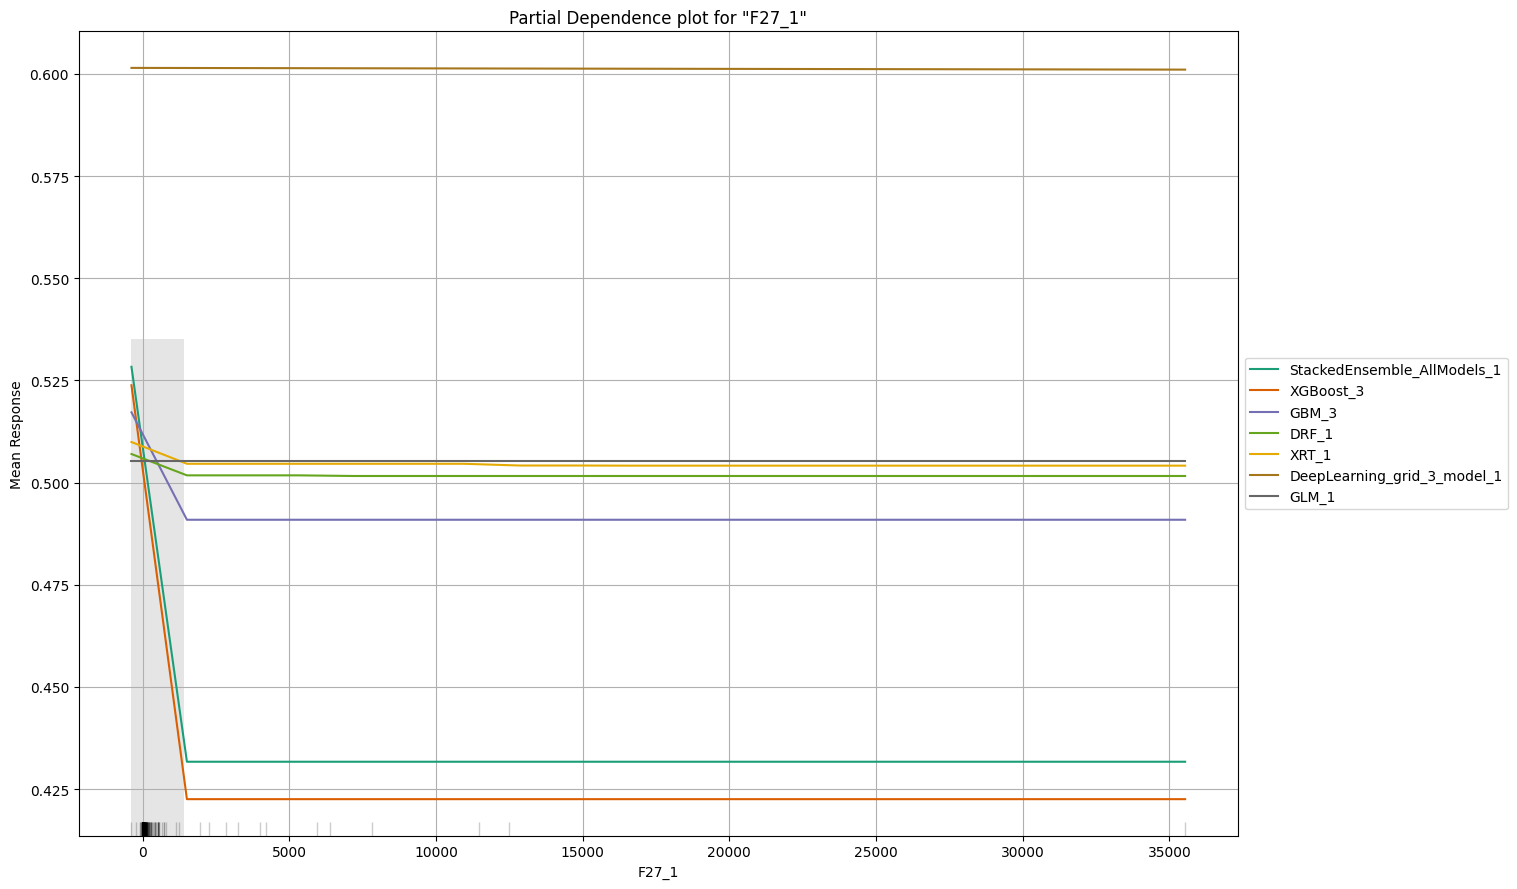

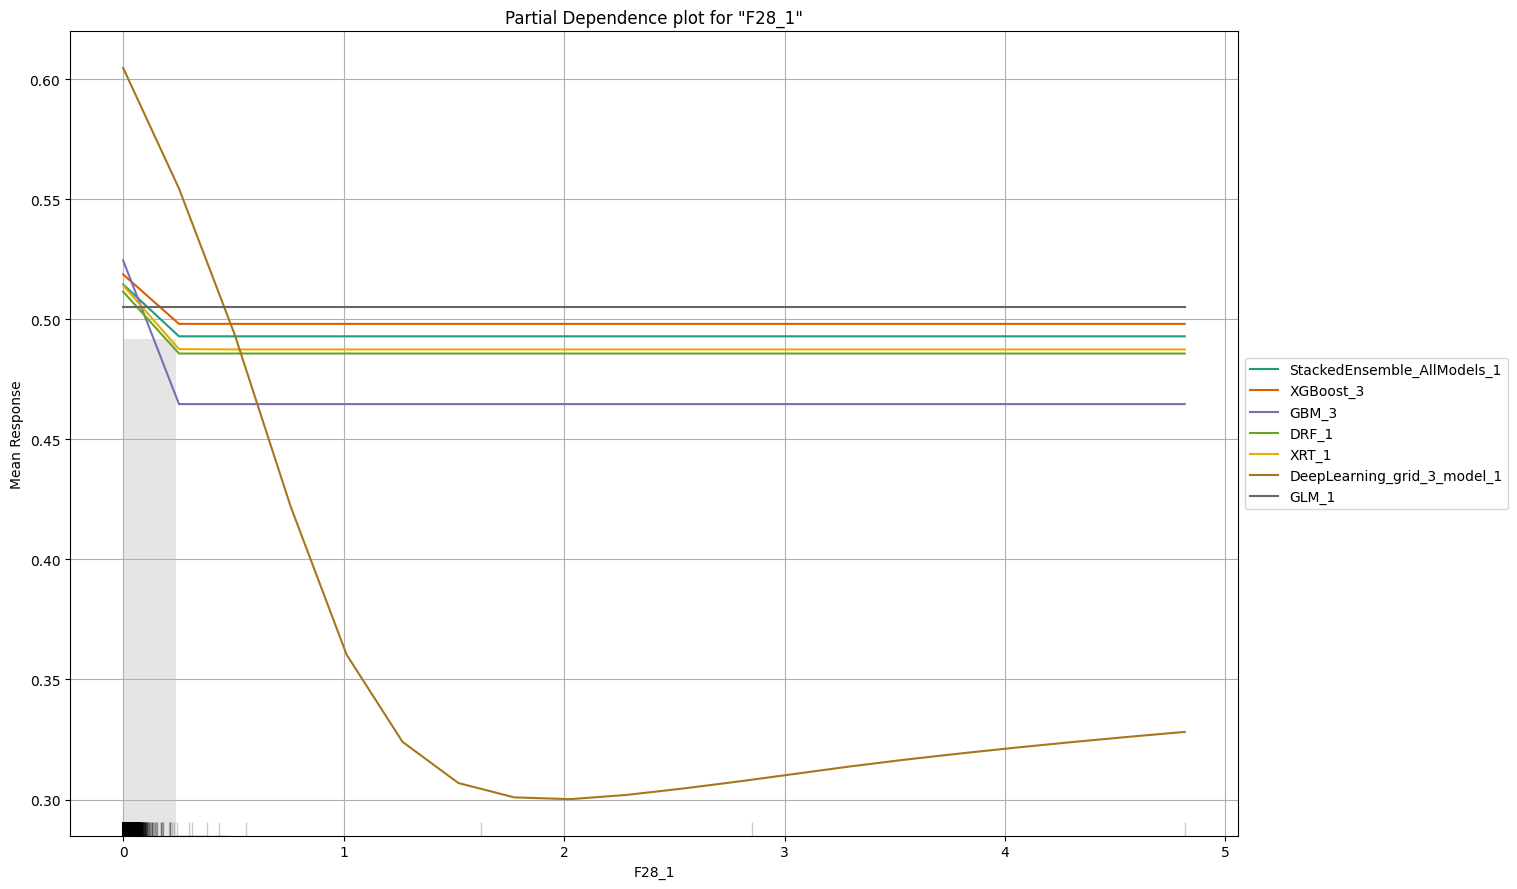

In [4]:
exa = aml.explain(test)

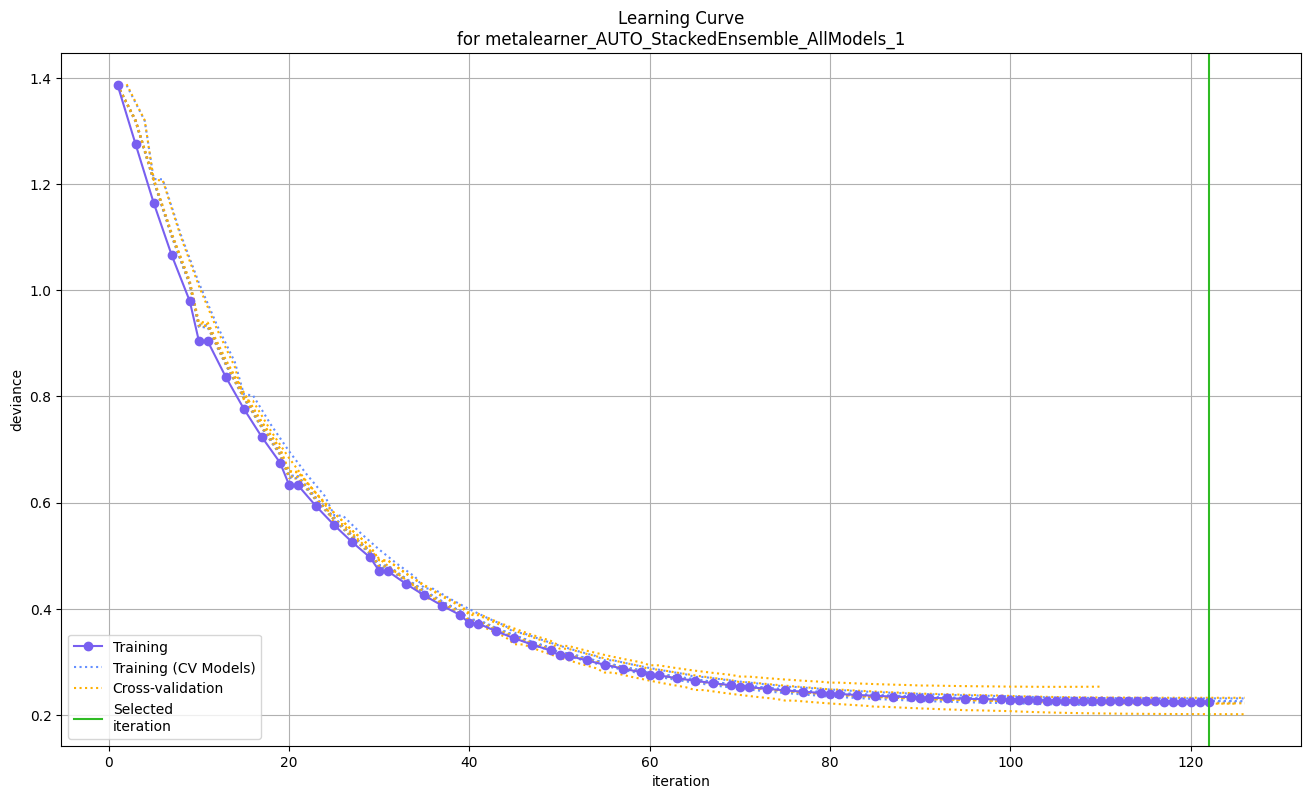

In [5]:
leader = aml.leader
learning_curve_plot = leader.learning_curve_plot()

### Pareto Front para decidir que algoritmos puede elegirse

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
StackedEnsemble_AllModels_1_AutoML_1_20230614_132707,0.991341,0.113137,0.990404,0.0412443,0.178314,0.0317958,12841,0.021804,StackedEnsemble
StackedEnsemble_BestOfFamily_1_AutoML_1_20230614_132707,0.990431,0.119015,0.989292,0.0436638,0.183205,0.0335642,6879,0.011913,StackedEnsemble
XGBoost_3_AutoML_1_20230614_132707,0.990123,0.122902,0.988908,0.0439119,0.185332,0.0343479,5006,0.002978,XGBoost
XGBoost_grid_1_AutoML_1_20230614_132707_model_2,0.99002,0.120265,0.988347,0.0436009,0.184024,0.0338647,4756,0.002709,XGBoost
GLM_1_AutoML_1_20230614_132707,0.912111,0.442045,0.874292,0.147248,0.357337,0.12769,10955,0.001614,GLM


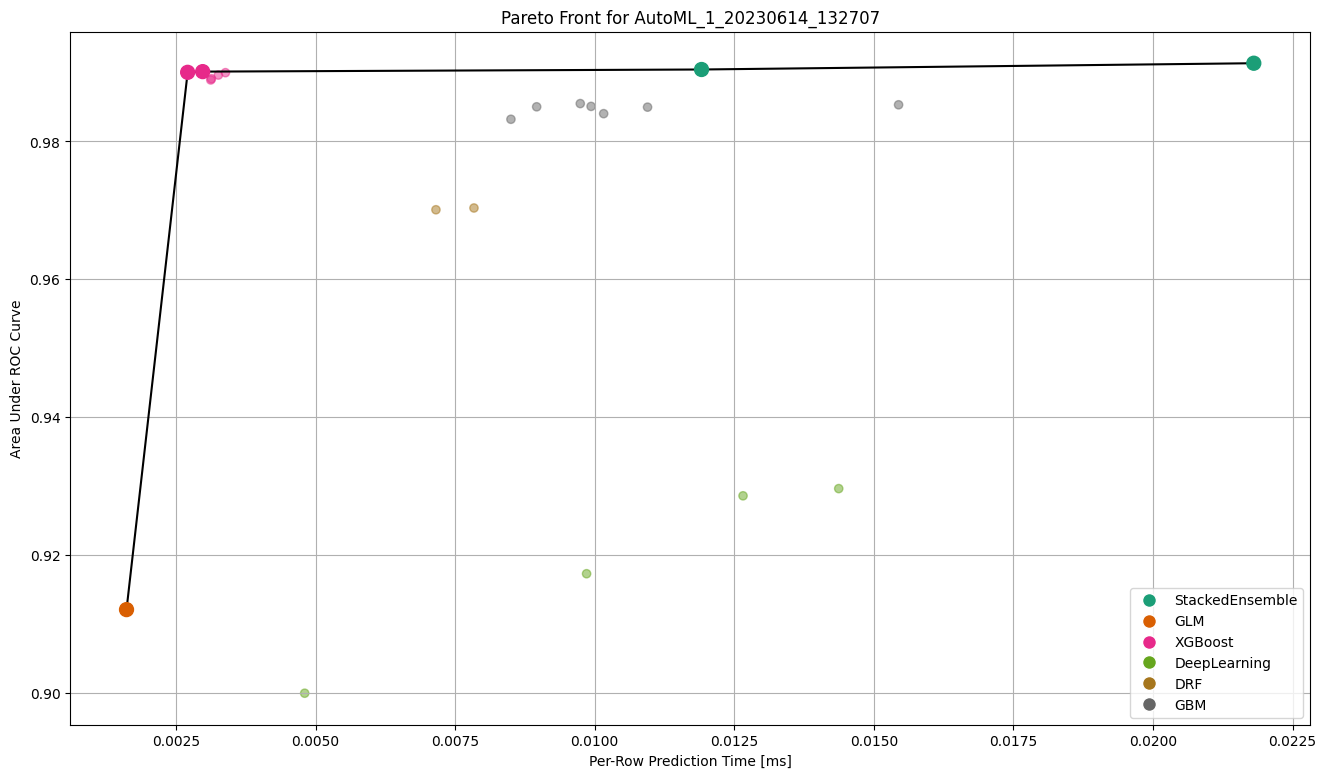

In [6]:
pf = aml.pareto_front(x_metric="predict_time_per_row_ms", y_metric="auc")
pf.figure()
pf

In [7]:
metalearner = aml.leader.metalearner()
metalearner.coef_norm()

{'Intercept': -0.6429584186999775,
 'XGBoost_3_AutoML_1_20230614_132707': 1.1545543835702496,
 'XGBoost_grid_1_AutoML_1_20230614_132707_model_2': 0.8718194787795966,
 'XGBoost_grid_1_AutoML_1_20230614_132707_model_3': 0.8275573869069797,
 'XGBoost_grid_1_AutoML_1_20230614_132707_model_1': 1.033731856086216,
 'XGBoost_2_AutoML_1_20230614_132707': 0.6836699658764814,
 'XGBoost_1_AutoML_1_20230614_132707': 0.6008522380178031,
 'GBM_3_AutoML_1_20230614_132707': 0.019990439311048578,
 'GBM_grid_1_AutoML_1_20230614_132707_model_2': 0.0,
 'GBM_2_AutoML_1_20230614_132707': 0.0,
 'GBM_4_AutoML_1_20230614_132707': 0.0,
 'GBM_1_AutoML_1_20230614_132707': 0.0,
 'GBM_5_AutoML_1_20230614_132707': 0.0,
 'GBM_grid_1_AutoML_1_20230614_132707_model_1': 0.0,
 'DRF_1_AutoML_1_20230614_132707': 0.0,
 'XRT_1_AutoML_1_20230614_132707': 0.0,
 'DeepLearning_grid_3_AutoML_1_20230614_132707_model_1': 0.0,
 'DeepLearning_grid_2_AutoML_1_20230614_132707_model_1': 0.0,
 'DeepLearning_grid_1_AutoML_1_20230614_132707

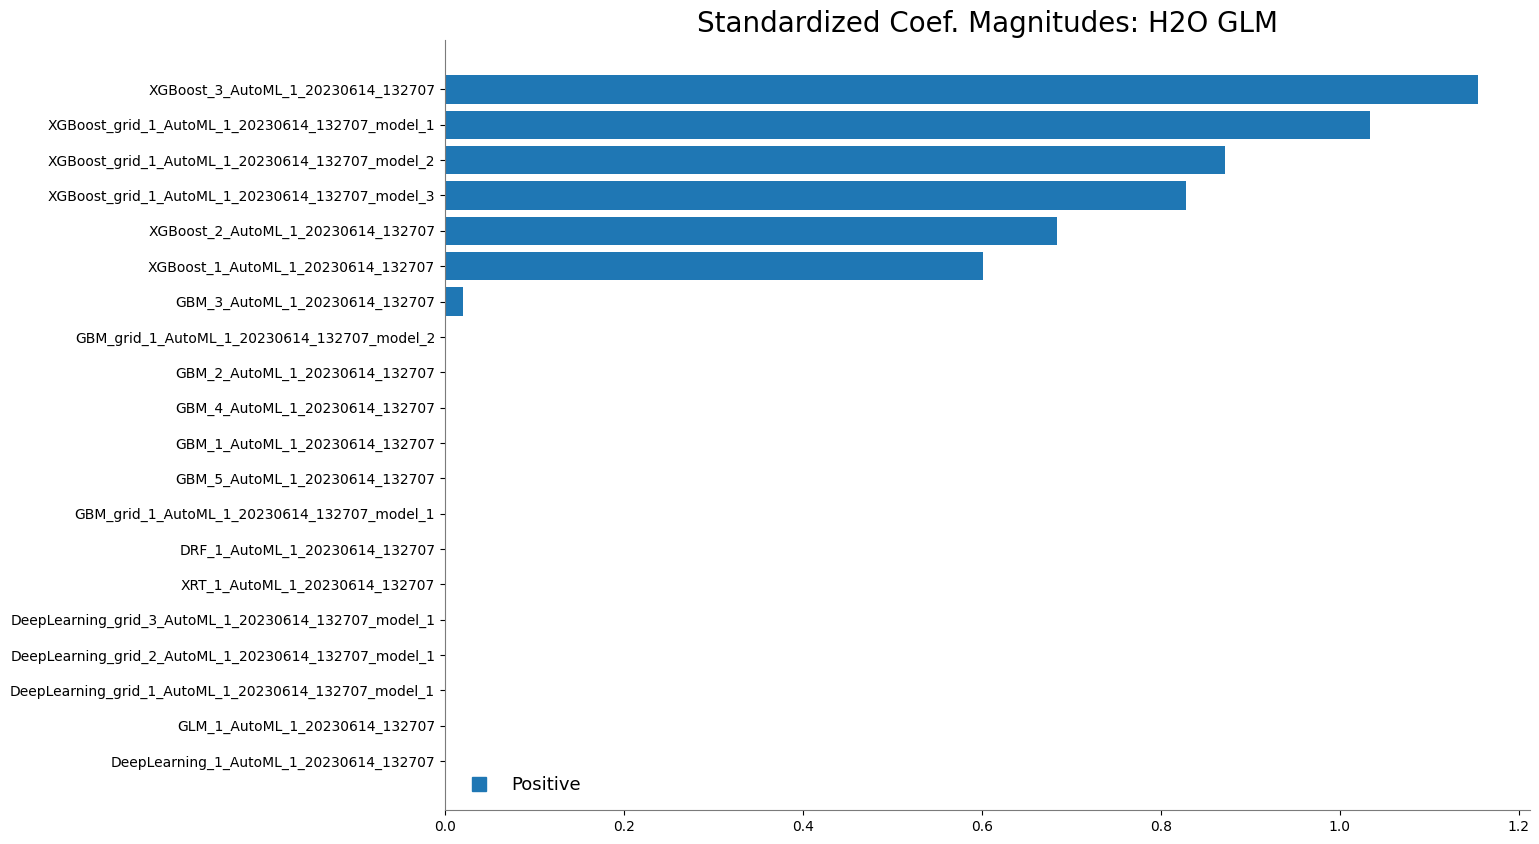

In [8]:
%matplotlib inline
metalearner.std_coef_plot()